In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("./data/incomeData.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df = df.apply(lambda x : x.str.strip() if x.dtype == "object" else x)

In [9]:
# In this dataset missing values have been denoted by '?'
# we are replacing ? with NaN for them to be imputed down the line.
df.replace('?', np.nan, inplace=True)

In [10]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
Income               0
dtype: int64

In [12]:
cols = df.columns
mc = []
a = df.isna().sum()
for i in range(15) : 
    if a[i] > 0 : 
        mc.append(cols[i])

C:\Users\brije\AppData\Local\Temp\ipykernel_14344\1824250414.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if a[i] > 0 :


In [14]:
mc

['workclass', 'occupation', 'native-country']

In [18]:
!pip install scikit-learn

  Using cached scikit_learn-1.6.1-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached scipy-1.15.2-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp313-cp313-win_amd64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached scipy-1.15.2-cp313-cp313-win_amd64.whl (41.0 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [29]:
# As the columns which have missing values, they are only categorical, we'll use the categorical imputer
# Importing the categorical imputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')

In [32]:
# Imputing missing values for categorical columns
df['workclass'] = imputer.fit_transform(df[['workclass']]).ravel()
df['occupation'] = imputer.fit_transform(df[['occupation']]).ravel()
df['native-country'] = imputer.fit_transform(df[['native-country']]).ravel()

In [34]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
Income            0
dtype: int64

In [35]:
# The education column has a corresponding education-num column which has numerical values
df.drop(columns=['education'] ,inplace=True)

In [36]:
# Extracting the categorical columns
cat_df = df.select_dtypes(include=['object']).copy()

In [37]:
cat_df.columns

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country', 'Income'],
      dtype='object')

In [38]:
cat_df.head()

,workclass,marital-status,occupation,relationship,race,sex,native-country,Income
0,State-gov,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [39]:
cat_df['Income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [40]:
cat_df['Income'] = cat_df['Income'].map({'<=50K': 0, '>50K': 1})

In [41]:
# Using the dummy encoding to encode the categorical columns to numericsl ones
for col in cat_df.drop('Income',axis=1).columns:
    x=cat_df[col].head(1)
    cat_df= pd.get_dummies(cat_df, columns=[col], prefix = [col], drop_first=True)
    

In [42]:
cat_df.head()

,Income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0,False,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,0,False,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [43]:
# extracting the numerical columns
num_df = df.select_dtypes(include=['int64']).copy()

In [44]:
num_df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(num_df)

In [47]:
scaled_num_df= pd.DataFrame(data=scaled_data, columns=num_df.columns)

In [48]:
scaled_num_df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [49]:
# combining the Numerical and categorical dataframes to get the final dataset
final_df=pd.concat([scaled_num_df,cat_df], axis=1)

In [50]:
final_df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,Income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [52]:
# separating the feature and target columns
X=final_df.drop('Income',axis=1)
y=final_df['Income']


If we plot the distribution of the target column, we'd find that the peole with less than 50K annual income are more in number than the people with an annual income greaterthan 50K


(array([24720.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  7841.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

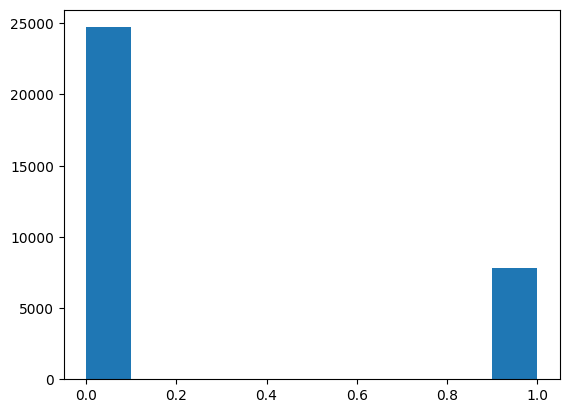

In [53]:
plt.hist(y)

Hence The dataset is imbalanced. we need to introduce some random sampling to make it balanced.

In [56]:
!pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)


In [58]:
from imblearn.over_sampling import RandomOverSampler

rdsmple = RandomOverSampler()
x_sampled , y_sampled = rdsmple.fit_resample(X ,y)

(array([24720.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 24720.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

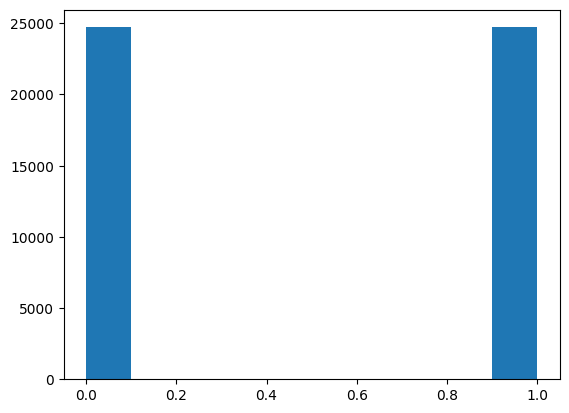

In [59]:
plt.hist(y_sampled)

As Shown above , Now the data looks to be balanced . 

In [60]:
# splitting the data into training and test set
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state= 42)

In [61]:
from sklearn.naive_bayes import  GaussianNB 
from sklearn.naive_bayes import CategoricalNB
gnb = GaussianNB(priors=None , var_smoothing=0.05) 

In [62]:
gnb_model = gnb.fit(x_train , y_train)

In [63]:
gnb_model

GaussianNB(var_smoothing=0.05)

In [64]:
y_pred = gnb_model.predict(x_test)

In [65]:
from sklearn.metrics import  accuracy_score , confusion_matrix , classification_report 

In [67]:
sc = accuracy_score(y_test , y_pred) 
sc

0.7970109530146381

In [68]:
from sklearn.model_selection import  GridSearchCV 

In [69]:
param_grid = {
    'var_smoothing' : [1e-9,0.1, 0.001, 0.5,0.05,0.01,1e-8,1e-7,1e-6,1e-10,1e-11]
}

In [70]:
grid = GridSearchCV(estimator= gnb , param_grid=param_grid , cv = 5 , verbose=3)


In [71]:
grid.fit(x_train , y_train )

Fitting 5 folds for each of 11 candidates, totalling 55 fits
[CV 1/5] END ...............var_smoothing=1e-09;, score=0.495 total time=   0.0s
[CV 2/5] END ...............var_smoothing=1e-09;, score=0.487 total time=   0.0s
[CV 3/5] END ...............var_smoothing=1e-09;, score=0.486 total time=   0.0s
[CV 4/5] END ...............var_smoothing=1e-09;, score=0.393 total time=   0.0s
[CV 5/5] END ...............var_smoothing=1e-09;, score=0.456 total time=   0.0s
[CV 1/5] END .................var_smoothing=0.1;, score=0.823 total time=   0.0s
[CV 2/5] END .................var_smoothing=0.1;, score=0.828 total time=   0.0s
[CV 3/5] END .................var_smoothing=0.1;, score=0.826 total time=   0.0s
[CV 4/5] END .................var_smoothing=0.1;, score=0.826 total time=   0.0s
[CV 5/5] END .................var_smoothing=0.1;, score=0.823 total time=   0.0s
[CV 1/5] END ...............var_smoothing=0.001;, score=0.711 total time=   0.0s
[CV 2/5] END ...............var_smoothing=0.001;

GridSearchCV(cv=5, estimator=GaussianNB(var_smoothing=0.05),
             param_grid={'var_smoothing': [1e-09, 0.1, 0.001, 0.5, 0.05, 0.01,
                                           1e-08, 1e-07, 1e-06, 1e-10, 1e-11]},
             verbose=3)

In [73]:
grid.best_params_

{'var_smoothing': 0.1}

In [75]:
!pip install xgboost 

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 818.6 kB/s eta 0:03:03
   ---------------------------------------- 0.5/150.0 MB 818.6 kB/s eta 0:03:03
   ---------------------------------------- 0.5/150.0 MB 818.6 kB/s eta 0:03:03
   ---------------------------------------- 0.8/150.0 MB 534.6 kB/s eta 0:04:40
   ---------------------------------------- 0.8/150.0 MB 534.6 kB/s eta 0:04:40
   ---------------------------------------- 0.8/150.0 MB 534.6 kB/s eta 0:04:40
   ---------------------------------------- 1.0/150.0 MB 531.0 kB/s eta 0:04:41
   ---------------------------------------- 1.0/150.0 MB 531.0 kB/s eta 0:04:41
   --

In [76]:
from xgboost import XGBClassifier

In [81]:
xgb=XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, criterion='gini', gamma=0,
              learning_rate=0.1, max_delta_step=0, max_depth=9,
              min_child_weight=1, missing=np.nan, n_estimators=130, n_jobs=1,
              nthread=None, objective='binary:logistic', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

In [82]:
xgb_model = xgb.fit(x_train , y_train)

d:\Practice program\DS\44 Income Prediction\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:33:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "criterion" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [83]:
y_pred = xgb_model.predict(x_test)

In [84]:
ac2 = accuracy_score(y_test , y_pred )
ac2

0.8712253045347528

In [85]:
param_grid = {
    "n_estimators": [10, 50, 100, 130], 
    "criterion": ['gini', 'entropy'],
    "max_depth": range(2, 10, 1)
    }

#Creating an object of the Grid Search class
grid = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5,  verbose=3,n_jobs=-1)

In [86]:
#finding the best parameters
grid.fit(x_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


d:\Practice program\DS\44 Income Prediction\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:34:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "criterion" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=0.5, booster='gbtree',
                                     callbacks=None, colsample_bylevel=1,
                                     colsample_bynode=1, colsample_bytree=1,
                                     criterion='gini', device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=0, grow_policy=None,
                                     importance_type=None,
                                     interaction_constra...,
                                     learning_rate=0.1, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None, max_delta_step=0,
                                     max_depth=9, max_leaves=None,
                                     min_child_weight=1, missing=nan,
                                     monotone_constraints=None,
                                     multi_strategy=None, n_estimators=130,
                                     n_jobs=1, ...),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 10),
                         'n_estimators': [10, 50, 100, 130]},
             verbose=3)

In [88]:
grid.best_estimator_

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              criterion='gini', device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=0, max_depth=5,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=130,
              n_jobs=1, ...)